# Get to Know a Dataset: [Version 2 High Resolution Canopy Height Maps by WRI and Meta]

This notebook serves as a guided tour of the [Version 2 High Resolution Canopy Height Maps by WRI and Meta](https://registry.opendata.aws/dataforgood-fb-forestsv2/) dataset. More usage examples, tutorials, and documentation for this dataset and others can be found at the [Registry of Open Data on AWS](https://registry.opendata.aws/).



### Q: How have you organized your dataset? Help us understand the key prefix structure of your S3 bucket.



At the top level of our S3 bucket ("dataforgood-fb-data"), we have a prefix "forests/v2/global/dinov3_global_chm_v2_ml3"  contains:

 1. "chm" containing canopy height maps as cloud optimized geotiffs.
 2. "metadata" containing geojsons with observation date across the dataset.
 3. "tiles.geojson" is a geojson containing the tile extent for each tile, and the associated quadkey name.
 
 Full documentation for this dataset can be found at: https://arxiv.org/abs/2603.06382





First we will import the Python libraries required throughout this notebook.

In [1]:
# This notebook requires the following additional libraries
# (please install using the preferred method for your environment, e.g. pip, conda):
#
# boto3 >= 1.38.23
# matplotlib >= 3.10.3 
# rasterio >= 1.5.0
# geopandas >= 1.1.3

# Import the libraries required for this notebook
# Built-ins
import json
from pprint import pprint
import tempfile
import os
# Installed libraries
import boto3, matplotlib.pyplot as plt
from botocore import UNSIGNED
from botocore.config import Config
import rasterio
import rasterio.mask
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gp
import numpy as np

Next, we will define the location of our dataset, create our boto3 S3 client, and list the top level prefixes in our S3 path:


In [2]:
# Location of the S3 bucket for this dataset
bucket = "dataforgood-fb-data"
path = "forests/v2/global/dinov3_global_chm_v2_ml3/"

# List the top level of the bucket using boto3. Because this is a public bucket, we don't need to sign requests.
# Here we set the signature version to unsigned, which is required for public buckets.
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# Print the items in the top-level prefixes
for item in s3.list_objects_v2(Bucket=bucket, Prefix=path, Delimiter='/')['CommonPrefixes']:
    print(item['Prefix'])


forests/v2/global/dinov3_global_chm_v2_ml3/chm/
forests/v2/global/dinov3_global_chm_v2_ml3/metadata/




Looking into the geotiff prefix of our dataset, we see a list of .tif files, with names cooresponding to quadkey tiles at zoom_level=10.


In [3]:
path = "forests/v2/global/dinov3_global_chm_v2_ml3/"


# each page has a max of 1000 items
paginator = s3.get_paginator("list_objects_v2")
pages = paginator.paginate(Bucket=bucket, Prefix=path)

outlist = []
#only print first page here
for page in pages:
    if "Contents" in page.keys():
        objlist = [i["Key"] for i in page["Contents"]]
        outlist.extend(objlist)
        break
#we only print 10 here
pprint(outlist[-10:])    

['forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222111.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222112.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222113.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222120.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222121.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222122.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222123.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222130.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222131.tif',
 'forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222132.tif']




### Q: What data formats are present in your dataset? What kinds of data are stored using these formats? Can you give any advice for how you work with these data formats?


Our dataset comes as a set of Cloud Optimized Geotiffs:

-  The extent of each geotiff is a zoom_level=10 [web mercator tile](https://en.wikipedia.org/wiki/Web_Mercator_projection).
-  The filenames are quadkeys of the containing tile.
-  Each geotiff contains a single data band, which represents the top of canopy height above the ground in meters.
-  The mask band of the geotiff is a boolean represnting where or not the input imagery has been flagged as containing a cloud.
-  The CRS is epsg:3857


The geojsons contain a set of polygons in a given tile. 
- Each polygon contains a single feature value, containing a string of the observation date of the input imagery. 


### Q: Can you show us an example of downloading and loading data from your dataset?

As an example, let us load up and look at one geotiff


In [4]:
#download chm
s3file="forests/v2/global/dinov3_global_chm_v2_ml3/chm/0022222122.tif"
with tempfile.NamedTemporaryFile(suffix=".tif") as dst:
    s3.download_file(bucket, s3file, dst.name)
    with rasterio.open(dst.name) as src:
        chm=src.read().squeeze()
        meta=src.meta
print(meta)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32768, 'height': 32768, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'), 'transform': Affine(1.19432856695596, 0.0, -19880965.308861203,
       0.0, -1.1943285669557895, 10214432.96380467)}


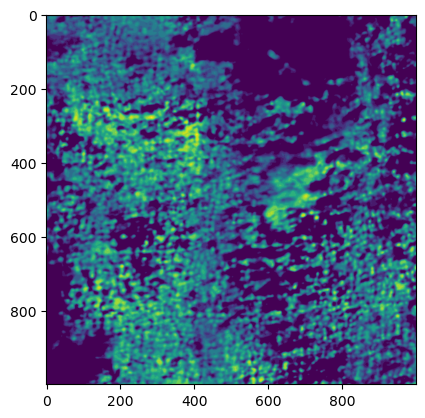

In [5]:
plt.imshow(chm[0:1000,0:1000])



### Q: What is one question that you have answered using these data? Can you show us how you came to that answer?

We have used the data to identify relative canopy height of two nearby areas. When evaluating forest restoration and carbon stroage potential, it is useful to compare the existing state of canopy volume (ie, integrated canopy height) for a gien area, compared to the canopy valume in a mature forest nearby. 

This example highlight the strengths of the dataset (high resolution canopy height estimates, available globally), while minimizing some weaknesses (errors related to view angle, data available from a single time) by making relative (rather than absolute) measurements.




### Q: What is one unanswered question that you think could be answered using these data? Do you have any recommendations or advice for someone wanting to answer this question?


The connection between canopy height maps and biomass is a challenging but important link for carbon markets. Solving this problem would be valuable for not just this type of dataset, but aerial lidar datasets as well.



### Q: Can you provide an example to demonstrate the type of analysis you can use this data for?

One problem we use dataset for is to estimate the distribution of canopy heights and calculate the total canopy volume within a potential restoration area. We'll start with a polygon region of interest (ROI) and produce canopy height hietograms within it and an estimate of total canopy volume.

In [6]:
# a few raster functions
localdir='/tmp'
def merge_rasters(files, outfile: str = "test.tif") -> None:
    """
    Merge a list of geotiffs into one file
    """
    src_files_to_mosaic = []
    for fp in files:
        src = rasterio.open(fp)
        src_files_to_mosaic.append(src)

    crs = src.crs
    out_meta = src.meta.copy()
    mosaic, out_trans = merge(src_files_to_mosaic)

    # Update the metadata
    out_meta.update(
        {
            "driver": "GTiff",
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": out_trans,
            "crs": crs,
        }
    )

    with rasterio.open(outfile, "w", **out_meta, compress="DEFLATE", BIGTIFF='YES') as dest:
        dest.write(mosaic)

def crop_raster(rasterfile: str, aoifile:str, outfile: str = "test.tif", nodata=255):
    gdf_aoi=gp.read_file(aoifile)
    with rasterio.open(rasterfile) as src:
            out_meta = src.meta.copy()
            if not src.crs == gdf_aoi.crs:
                gdf_aoi=gdf_aoi.to_crs(src.crs)
            aoi=gdf_aoi.iloc[0].geometry
            im, trans = rasterio.mask.mask(
                src, [aoi], crop=True, nodata=nodata, all_touched=True
            )
            # Update the metadata
            out_meta.update(
            {
                "driver": "GTiff",
                "height": im.shape[1],
                "width": im.shape[2],
                "transform": trans,
                "crs": src.crs,
                "nodata": nodata,
            }
            )
    with rasterio.open(outfile, "w", **out_meta, compress="DEFLATE", BIGTIFF='YES') as dest:
        dest.write(im)


def get_utm_epsg(longitude: float, latitude: float) -> int:
    """Return the EPSG code for the UTM zone covering the given lon/lat."""
    zone_number = int((longitude + 180) / 6) + 1
    if latitude >= 0:
        return 32600 + zone_number  # Northern hemisphere
    return 32700 + zone_number  # Southern hemisphere


def reproject_to_utm(src_path: str, dst_path: str, resampling=Resampling.nearest) -> int:
    """Reproject a raster to the appropriate UTM zone.

    Determines the UTM zone from the centroid of the raster's bounds
    (transformed to EPSG:4326) and reprojects into that zone.

    Args:
        src_path: Path to the input raster.
        dst_path: Path for the output raster.
        resampling: Resampling method (default: nearest).

    Returns:
        The EPSG code of the destination UTM CRS.
    """
    with rasterio.open(src_path) as src:
        # Get bounds in geographic coordinates to determine UTM zone
        bounds_4326 = rasterio.warp.transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        center_lon = (bounds_4326[0] + bounds_4326[2]) / 2
        center_lat = (bounds_4326[1] + bounds_4326[3]) / 2
        dst_epsg = get_utm_epsg(center_lon, center_lat)
        dst_crs = f"EPSG:{dst_epsg}"

        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )

        kwargs = src.meta.copy()
        kwargs.update(
            crs=dst_crs,
            transform=transform,
            width=width,
            height=height,
        )

        with rasterio.open(dst_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=resampling,
                )

    return dst_crs


In [7]:
#chm geotiffs are tiled in web mercator tiles globally
#download poygons for global tiles
s3file=f'{path}tiles.geojson'
with tempfile.NamedTemporaryFile(suffix=".tif") as dst:
    s3.download_file(bucket, s3file, dst.name)
    gdf = gp.read_file(dst.name)

In [8]:
#here is the polygon that contains the area of interest (AOI)
#Note: Input as string for convienence here and saved as geojson locally
json_str='{"type":"FeatureCollection","features":[{"type":"Feature","properties":{},"geometry":{"coordinates":[[[-124.44821128650707,47.96375971105218],[-124.4562141522843,47.957235346169256],[-124.45369793868576,47.94745207162097],[-124.43255639513018,47.94353826197866],[-124.4215544425468,47.9507096893669],[-124.4303921269132,47.95471897052806],[-124.42616003999984,47.9595611153465],[-124.43408808588893,47.9665425958913],[-124.44821128650707,47.96375971105218]]],"type":"Polygon"}}]}'
with open(f'{localdir}/example_aoi.geojson', 'w') as f:
    f.write(json_str)

In [9]:
#now read the polygon
target_polyfile=f'{localdir}/example_aoi.geojson'
target=gp.read_file(target_polyfile)
tt=target.to_crs(gdf.crs)

In [10]:
#find tile(s) that contain the target polygon
target_tiles=gp.sjoin(gdf, tt)

In [11]:
tifs=[]
for ii, row in target_tiles.iterrows():
    print(row.tile)

    #download chm
    s3file=f"forests/v2/global/dinov3_global_chm_v2_ml3/chm/{row.tile}.tif"
    localfile=f"{localdir}/{os.path.basename(s3file)}"
    if not os.path.exists(localfile):
        s3.download_file(bucket, s3file, localfile)
        
    tifs.append(localfile)

0212211310
0212211301


In [12]:
#merge all tile tiffs into one continuous tif
mergefile=f"{localdir}/aoi_alltiles.tif"
if not os.path.exists(mergefile):
    merge_rasters(tifs, outfile=mergefile)

In [13]:
#reproject to utm for equal area meter pixels
utmfile=mergefile.replace('_alltiles.tif', '_utm.tif')
if not os.path.exists(utmfile):
    utm_crs=reproject_to_utm(mergefile, utmfile)

In [14]:
#crop to bounds of input polygon
cropfile=utmfile.replace('_utm.tif', '_crop.tif')
if not os.path.exists(cropfile):
    crop_raster(utmfile, target_polyfile, cropfile)

In [15]:
#read the chm raster data
with rasterio.open(cropfile) as src:
    data = src.read(masked=True).astype(rasterio.float32)
    # Fill the masked values with NaN
    chm = data.filled(np.nan).squeeze()
    pixel_area=np.abs(src.transform[0]*src.transform[4])

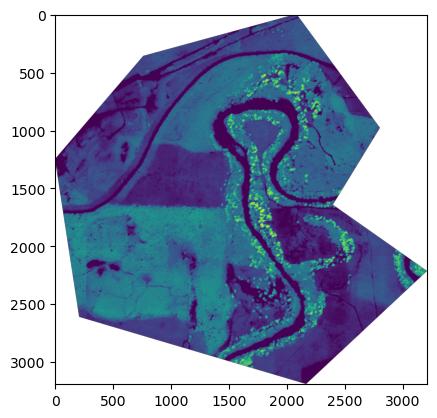

In [16]:
#show canopy height data within AOI
plt.imshow(chm)

Text(0.5, 1.0, 'canopy height distribution')

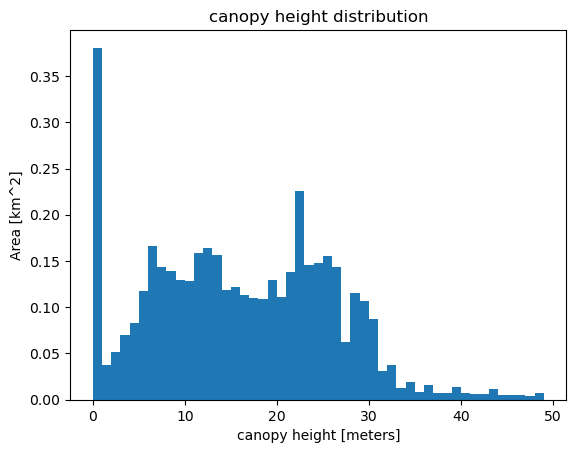

In [17]:
#histogram of canopy height across area
chm_flat=chm.flatten()
bins=np.arange(0,50)
plt.hist(chm_flat, bins=bins, weights=np.ones(len(chm_flat))*pixel_area/1e6)
plt.xlabel('canopy height [meters]')
plt.ylabel('Area [km^2]')
plt.title('canopy height distribution')

In [18]:
#print the total vegetation volume within the ROI
f"total vegetation volume in ROI: {np.round(float(np.nansum(chm)*pixel_area*1e-9),3)} km^3" 

'total vegetation volume in ROI: 0.068 km^3'